## Credit Card Fraud Detection — Phase 1: EDA
ULB Credit Card Fraud Dataset
 
Steps:
  1. Load data & first look
  2. Class imbalance analysis
  3. Amount and Time distributions
  4. Log-transform Amount
  5. Violin plots — top PCA features by class

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
COLORS = {0: "#4C72B0", 1: "#E07070"}   # 0 = legit, 1 = fraud
LABELS = {0: "Legit", 1: "Fraud"}

In [2]:
# Load dataset
print("Loading creditcard.csv...")
df = pd.read_csv("creditcard.csv")

# Quick overview
print(f"\nShape: {df.shape}")
print(f"Missing: {df.isna().sum().sum()}")

# Target variable breakdown
print("\nClass Distribution:")
print(df['Class'].value_counts())

# Basic data preview
print("\nData Sample:")
print(df.head())


Loading creditcard.csv...

Shape: (284807, 31)
Missing: 0

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Data Sample:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.0052

--- Class Imbalance ---
Legitimate: 284,315 (99.83%)
Fraud:      492 (0.17%)
Baseline Accuracy (predicting all legit): 99.83%


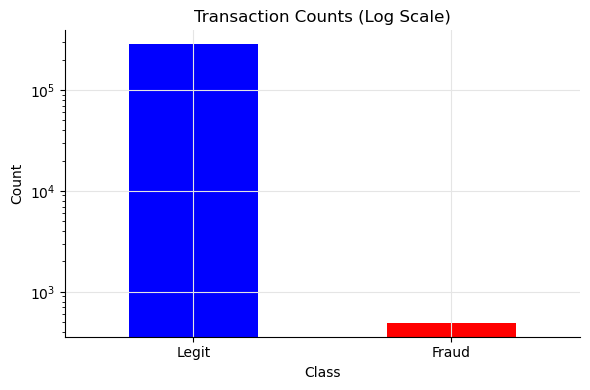

In [3]:
# Calculate counts and percentages
counts = df["Class"].value_counts()
pcts = df["Class"].value_counts(normalize=True) * 100

# Print statistics directly
print("--- Class Imbalance ---")
print(f"Legitimate: {counts[0]:,} ({pcts[0]:.2f}%)")
print(f"Fraud:      {counts[1]:,} ({pcts[1]:.2f}%)")
print(f"Baseline Accuracy (predicting all legit): {pcts[0]:.2f}%")

# Plot standard bar chart (Log scale helps see the fraud spike)
plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["blue", "red"])
plt.yscale("log")
plt.title("Transaction Counts (Log Scale)")
plt.xticks([0, 1], ["Legit", "Fraud"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

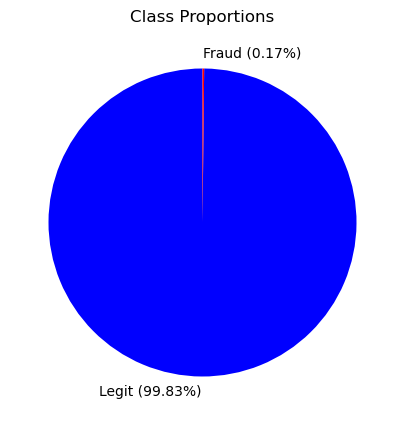

In [4]:
# Simplified Pie Chart
plt.figure(figsize=(5, 5))
plt.pie(
    counts, 
    labels=[f"Legit ({pcts[0]:.2f}%)", f"Fraud ({pcts[1]:.2f}%)"], 
    colors=["blue", "red"], 
    startangle=90
)
plt.title("Class Proportions")
plt.show()

## Class Imbalance Distribution


CLASS IMBALANCE
  Legitimate : 284,315  (99.8273%)
  Fraud      :     492  (0.1727%)
  Ratio      : 1 fraud per 578 legitimate transactions

  A model predicting 'legit' for everything achieves:
  Accuracy = 99.83%  ← completely useless
  This is why we use Precision-Recall AUC, not accuracy.


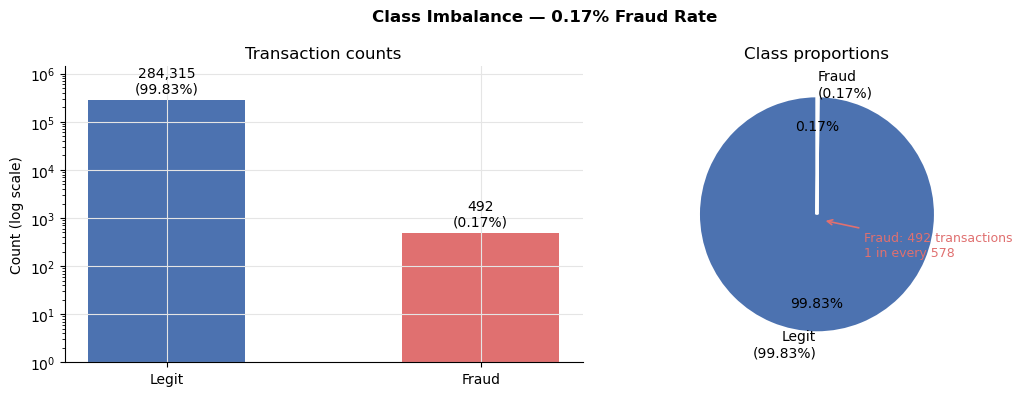

In [6]:
counts      = df["Class"].value_counts().sort_index()
pcts        = df["Class"].value_counts(normalize=True).sort_index() * 100
fraud_ratio = counts[1] / counts[0]
 
print("\n" + "=" * 60)
print("CLASS IMBALANCE")
print("=" * 60)
print(f"  Legitimate : {counts[0]:>7,}  ({pcts[0]:.4f}%)")
print(f"  Fraud      : {counts[1]:>7,}  ({pcts[1]:.4f}%)")
print(f"  Ratio      : 1 fraud per {1/fraud_ratio:.0f} legitimate transactions")
print(f"\n  A model predicting 'legit' for everything achieves:")
print(f"  Accuracy = {pcts[0]:.2f}%  ← completely useless")
print(f"  This is why we use Precision-Recall AUC, not accuracy.")
 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Class Imbalance — 0.17% Fraud Rate", fontweight="bold")
 
# Bar chart — log scale to show both classes
ax = axes[0]
bars = ax.bar([LABELS[0], LABELS[1]], counts.values,
              color=[COLORS[0], COLORS[1]], width=0.5)
ax.set_yscale("log")
ax.set_ylabel("Count (log scale)")
ax.set_title("Transaction counts")
for bar, (cls, cnt) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.4,
            f"{cnt:,}\n({pcts[cls]:.2f}%)",
            ha="center", fontsize=10)
ax.set_ylim(1, counts[0] * 5)
 
# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[f"Legit\n({pcts[0]:.2f}%)", f"Fraud\n({pcts[1]:.2f}%)"],
    colors=[COLORS[0], COLORS[1]],
    autopct=lambda p: f"{p:.2f}%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)
ax2.set_title("Class proportions")
ax2.grid(False)
# Fraud slice is tiny — zoom in with an annotation
ax2.annotate(f"Fraud: {counts[1]:,} transactions\n1 in every {1/fraud_ratio:.0f}",
             xy=(0.05, -0.05), xytext=(0.4, -0.35),
             fontsize=9, color=COLORS[1],
             arrowprops=dict(arrowstyle="->", color=COLORS[1], lw=1.2))
 
plt.tight_layout()
plt.savefig("phase1_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

## Amount Distribution -- Raw vs log Transform


AMOUNT DISTRIBUTION
  Raw    — mean: €88.35  median: €22.00  max: €25691.16  skew: 16.98
  Log    — mean: 3.152  median: 3.135  skew: 0.16

  Fraud amount stats:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


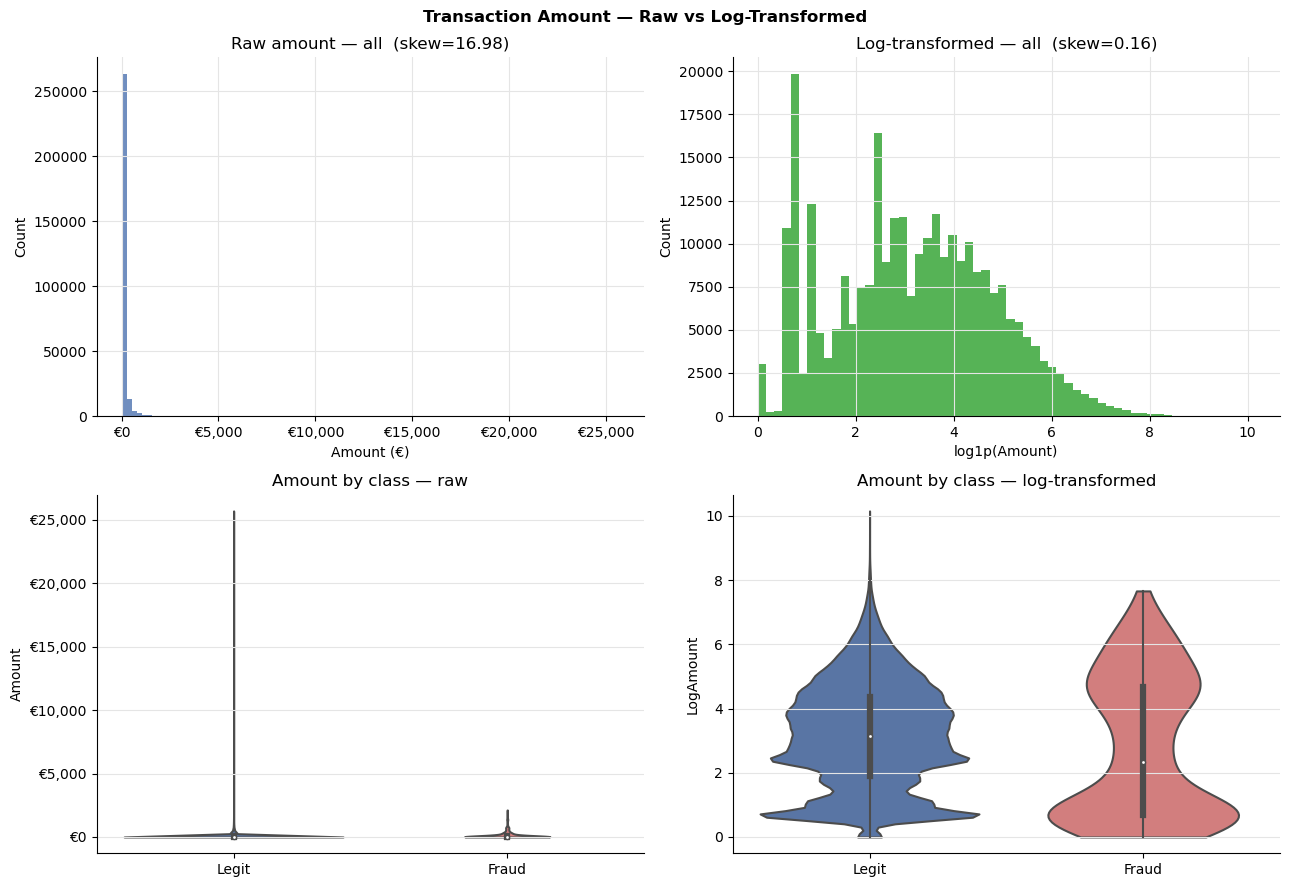

In [5]:
df["LogAmount"] = np.log1p(df["Amount"])
 
print("\n" + "=" * 60)
print("AMOUNT DISTRIBUTION")
print("=" * 60)
print(f"  Raw    — mean: €{df['Amount'].mean():.2f}  "
      f"median: €{df['Amount'].median():.2f}  "
      f"max: €{df['Amount'].max():.2f}  "
      f"skew: {df['Amount'].skew():.2f}")
print(f"  Log    — mean: {df['LogAmount'].mean():.3f}  "
      f"median: {df['LogAmount'].median():.3f}  "
      f"skew: {df['LogAmount'].skew():.2f}")
 
# Fraud vs legit amount stats
print(f"\n  Fraud amount stats:")
print(df.groupby("Class")["Amount"].describe().round(2).to_string())
 
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Transaction Amount — Raw vs Log-Transformed", fontweight="bold")
 
# Panel 1: Raw — all transactions
ax = axes[0, 0]
ax.hist(df["Amount"], bins=100, color="#4C72B0", edgecolor="none", alpha=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_title(f"Raw amount — all  (skew={df['Amount'].skew():.2f})")
ax.set_xlabel("Amount (€)")
ax.set_ylabel("Count")
 
# Panel 2: Log — all transactions
ax = axes[0, 1]
ax.hist(df["LogAmount"], bins=60, color="#2ca02c", edgecolor="none", alpha=0.8)
ax.set_title(f"Log-transformed — all  (skew={df['LogAmount'].skew():.2f})")
ax.set_xlabel("log1p(Amount)")
ax.set_ylabel("Count")
 
# Panel 3: Amount by class — violin
ax = axes[1, 0]
df["ClassLabel"] = df["Class"].map(LABELS)
sns.violinplot(data=df, x="ClassLabel", y="Amount",
               palette={"Legit": COLORS[0], "Fraud": COLORS[1]},
               inner="box", cut=0, ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_title("Amount by class — raw")
ax.set_xlabel("")
 
# Panel 4: LogAmount by class — violin
ax = axes[1, 1]
sns.violinplot(data=df, x="ClassLabel", y="LogAmount",
               palette={"Legit": COLORS[0], "Fraud": COLORS[1]},
               inner="box", cut=0, ax=ax)
ax.set_title("Amount by class — log-transformed")
ax.set_xlabel("")
 
plt.tight_layout()
# plt.savefig("phase1_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Time Distribution


TIME DISTRIBUTION
  Span: 48.0 hours (~2 days of transactions)
  Fraud transactions across time:
          count   mean    std   min    25%    50%    75%    max
Class                                                          
0      284315.0  26.34  13.19  0.00  15.06  23.53  38.70  48.00
1         492.0  22.43  13.29  0.11  11.46  20.99  35.69  47.32


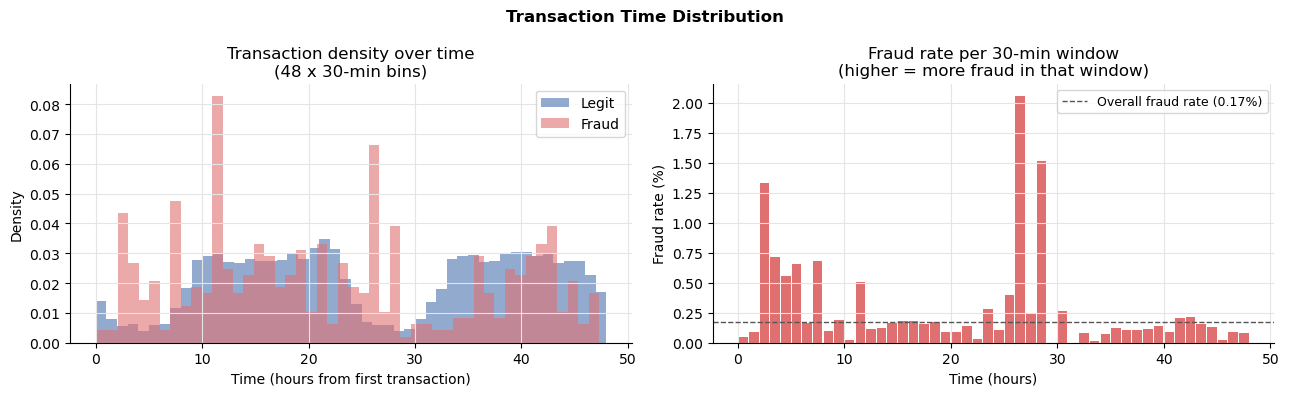

In [7]:
# Time is in seconds from the first transaction — convert to hours
df["TimeHours"] = df["Time"] / 3600
 
print("\n" + "=" * 60)
print("TIME DISTRIBUTION")
print("=" * 60)
print(f"  Span: {df['TimeHours'].max():.1f} hours (~2 days of transactions)")
print(f"  Fraud transactions across time:")
print(df.groupby("Class")["TimeHours"].describe().round(2).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Transaction Time Distribution", fontweight="bold")
 
# Panel 1: All transactions over time (density)
ax = axes[0]
for cls in [0, 1]:
    subset = df.loc[df["Class"] == cls, "TimeHours"]
    ax.hist(subset, bins=48, alpha=0.6, color=COLORS[cls],
            label=LABELS[cls], density=True, edgecolor="none")
ax.set_xlabel("Time (hours from first transaction)")
ax.set_ylabel("Density")
ax.set_title("Transaction density over time\n(48 x 30-min bins)")
ax.legend()
 
# Panel 2: Fraud rate per hour bin
ax2 = axes[1]
df["HourBin"] = pd.cut(df["TimeHours"], bins=48)
fraud_rate = df.groupby("HourBin", observed=False)["Class"].mean() * 100
hour_mids  = [iv.mid for iv in fraud_rate.index]
ax2.bar(hour_mids, fraud_rate.values, color="#E07070",
        width=(df["TimeHours"].max() / 48) * 0.9, edgecolor="none")
ax2.axhline(pcts[1], color="#555", linestyle="--",
            linewidth=1, label=f"Overall fraud rate ({pcts[1]:.2f}%)")
ax2.set_xlabel("Time (hours)")
ax2.set_ylabel("Fraud rate (%)")
ax2.set_title("Fraud rate per 30-min window\n(higher = more fraud in that window)")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase1_time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## PCA FEATURE SEPARATION — FIND MOST DISCRIMINATIVE FEATURES

In [9]:
# Rank PCA features by how well they separate fraud from legit
# Use absolute difference of medians (robust to outliers)
pca_cols   = [f"V{i}" for i in range(1, 29)]
separation = {}
 
for col in pca_cols:
    med_legit = df.loc[df["Class"] == 0, col].median()
    med_fraud = df.loc[df["Class"] == 1, col].median()
    # Also compute t-test p-value
    t_stat, p_val = stats.ttest_ind(
        df.loc[df["Class"] == 0, col].sample(5000, random_state=42),
        df.loc[df["Class"] == 1, col],
        equal_var=False
    )
    separation[col] = {
        "med_legit"   : med_legit,
        "med_fraud"   : med_fraud,
        "abs_diff"    : abs(med_fraud - med_legit),
        "p_value"     : p_val,
    }
 
sep_df   = pd.DataFrame(separation).T.sort_values("abs_diff", ascending=False)
top8     = sep_df.head(8).index.tolist()
 
print("\n" + "=" * 60)
print("PCA FEATURE SEPARATION — TOP 8")
print("=" * 60)
print(f"{'Feature':<8} {'Legit median':>14} {'Fraud median':>14} {'|Diff|':>8}")
print("-" * 50)
for feat in top8:
    row = sep_df.loc[feat]
    print(f"  {feat:<6}   {row['med_legit']:>12.3f}   "
          f"{row['med_fraud']:>12.3f}   {row['abs_diff']:>8.3f}")
 


PCA FEATURE SEPARATION — TOP 8
Feature    Legit median   Fraud median   |Diff|
--------------------------------------------------
  V14             0.052         -6.730      6.782
  V12             0.142         -5.503      5.644
  V3              0.182         -5.075      5.257
  V17            -0.065         -5.303      5.238
  V10            -0.092         -4.579      4.487
  V4             -0.022          4.177      4.200
  V11            -0.035          3.586      3.621
  V16             0.067         -3.550      3.617


## VIOLIN PLOTS — TOP 8 PCA FEATURES BY CLASS

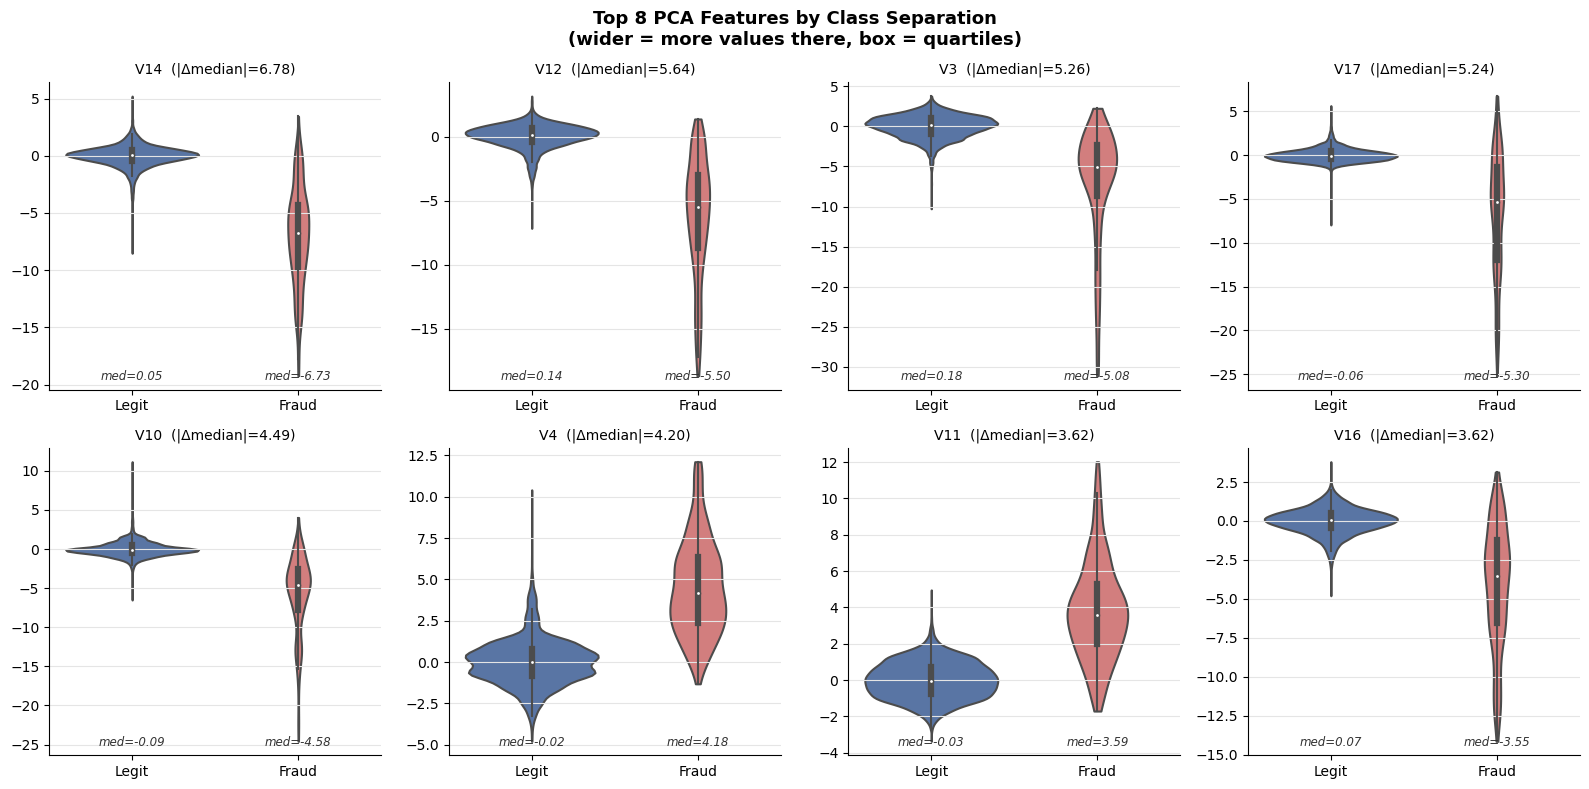

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Top 8 PCA Features by Class Separation\n"
             "(wider = more values there, box = quartiles)",
             fontweight="bold", fontsize=13)
axes = axes.flatten()
 
for ax, feat in zip(axes, top8):
    # Sample legit for speed (violin on 284k rows is slow)
    legit_sample = df.loc[df["Class"] == 0, feat].sample(5000, random_state=42)
    fraud_all    = df.loc[df["Class"] == 1, feat]
 
    plot_df = pd.concat([
        pd.DataFrame({"Value": legit_sample, "Class": "Legit"}),
        pd.DataFrame({"Value": fraud_all,    "Class": "Fraud"}),
    ])
 
    sns.violinplot(data=plot_df, x="Class", y="Value",
                   palette={"Legit": COLORS[0], "Fraud": COLORS[1]},
                   order=["Legit", "Fraud"],
                   inner="box", cut=0, ax=ax)
 
    # Annotate medians
    for j, (cls_label, cls_id) in enumerate([("Legit", 0), ("Fraud", 1)]):
        med = df.loc[df["Class"] == cls_id, feat].median()
        ax.text(j, ax.get_ylim()[0] +
                (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03,
                f"med={med:.2f}", ha="center",
                fontsize=8.5, color="#333", style="italic")
 
    diff = sep_df.loc[feat, "abs_diff"]
    ax.set_title(f"{feat}  (|Δmedian|={diff:.2f})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
 
plt.tight_layout()
plt.savefig("phase1_violin_pca_features.png", dpi=150, bbox_inches="tight")
plt.show()

## CORRELATION HEATMAP — TOP FEATURES WITH TARGET


Top 5 negatively correlated with fraud:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965

Top 5 positively correlated with fraud:
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549


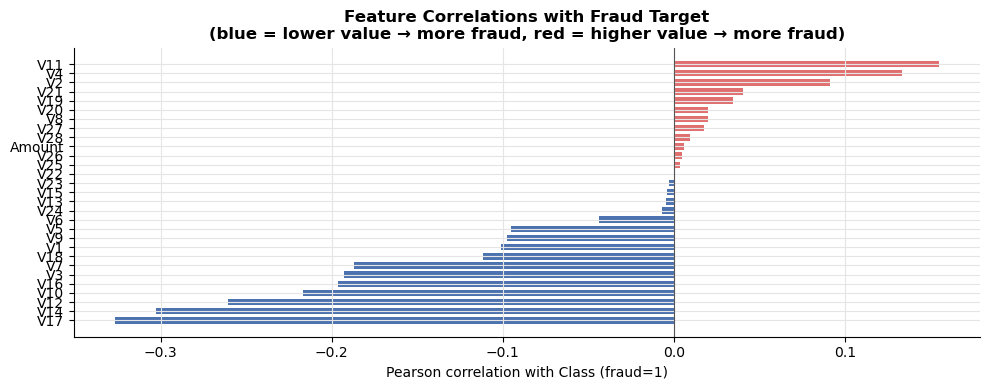

In [11]:
target_corr = (df[pca_cols + ["Amount", "Class"]]
               .corr()["Class"]
               .drop("Class")
               .sort_values())
 
print("\nTop 5 negatively correlated with fraud:")
print(target_corr.head(5).round(4).to_string())
print("\nTop 5 positively correlated with fraud:")
print(target_corr.tail(5).round(4).to_string())
 
fig, ax = plt.subplots(figsize=(10, 4))
colors  = [COLORS[1] if v > 0 else COLORS[0] for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, height=0.7)
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Class (fraud=1)")
ax.set_title("Feature Correlations with Fraud Target\n"
             "(blue = lower value → more fraud, red = higher value → more fraud)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("phase1_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# SUMMARY

print("\n" + "=" * 60)
print("PHASE 1 SUMMARY")
print("=" * 60)
print(f"  Total transactions : {len(df):,}")
print(f"  Fraud cases        : {counts[1]:,}  ({pcts[1]:.4f}%)")
print(f"  Legit cases        : {counts[0]:,}  ({pcts[0]:.4f}%)")
print(f"  Imbalance ratio    : 1:{1/fraud_ratio:.0f}")
print(f"  Top 3 features     : {', '.join(top8[:3])}")
print(f"  Amount skew (raw)  : {df['Amount'].skew():.2f}  → log-transform applied")
print(f"  Time span          : {df['TimeHours'].max():.1f} hours")
print(f"\n  Key modelling implications:")
print(f"    - Use PR-AUC not ROC-AUC or accuracy")
print(f"    - Apply SMOTE only to training data")
print(f"    - Scale Amount and Time (V1-V28 already scaled)")
print(f"    - Focus evaluation on Recall and FN count")
 
print("\nSaved:")
print("  phase1_class_imbalance.png")
print("  phase1_amount_distribution.png")
print("  phase1_time_distribution.png")
print("  phase1_violin_pca_features.png")
print("  phase1_feature_correlations.png")
print("\nNext: Phase 2 — SMOTE & supervised models")


PHASE 1 SUMMARY
  Total transactions : 284,807
  Fraud cases        : 492  (0.1727%)
  Legit cases        : 284,315  (99.8273%)
  Imbalance ratio    : 1:578
  Top 3 features     : V14, V12, V3
  Amount skew (raw)  : 16.98  → log-transform applied
  Time span          : 48.0 hours

  Key modelling implications:
    - Use PR-AUC not ROC-AUC or accuracy
    - Apply SMOTE only to training data
    - Scale Amount and Time (V1-V28 already scaled)
    - Focus evaluation on Recall and FN count

Saved:
  phase1_class_imbalance.png
  phase1_amount_distribution.png
  phase1_time_distribution.png
  phase1_violin_pca_features.png
  phase1_feature_correlations.png

Next: Phase 2 — SMOTE & supervised models
